# PHASE 3: CONVERTING FROM .CSV FORMAT TO PARQUET
## Check for Missing Values, Data Types, Saving to Parquet form

In [1]:
import pandas as pd

df = pd.read_csv("E:\INCOIS_Internhip\Data\Clean_Data.csv")

#Check total missing values per column
print(df.isna().sum())

WMOID           0
CYCLE           0
DATES           0
LON             0
LAT             0
Depth(m)        0
TEMP(degC)      0
PSAL(psu)       0
Temp_QC_Flag    0
PSAL_QC_Flag    0
dtype: int64


In [2]:
# Data types of columns
print(df.dtypes)

WMOID             int64
CYCLE             int64
DATES            object
LON             float64
LAT             float64
Depth(m)        float64
TEMP(degC)      float64
PSAL(psu)       float64
Temp_QC_Flag    float64
PSAL_QC_Flag    float64
dtype: object


In [3]:
import numpy as np
import xarray as xr

df["DATES"] = pd.to_datetime(
    df["DATES"],
    format="mixed",
    errors="raise"
)

print(df["DATES"].dtype)  #Verification
print(df["DATES"].head())

datetime64[ns]
0   2005-12-21 08:34:00
1   2005-12-21 08:34:00
2   2005-12-21 08:34:00
3   2005-12-21 08:34:00
4   2005-12-21 08:34:00
Name: DATES, dtype: datetime64[ns]


In [4]:
df['time_days'] = (df['DATES'] - df['DATES'].min()).dt.total_seconds() / 86400
df['doy'] = df['DATES'].dt.dayofyear

df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365.25)

# Correct way to check dtypes of multiple columns
print(df[['doy_sin', 'doy_cos']].dtypes)

doy_sin    float64
doy_cos    float64
dtype: object


In [5]:
df = df.drop(columns=["Temp_QC_Flag", "PSAL_QC_Flag"])

In [6]:
schema = {
    "WMOID": "int64",
    "CYCLE": "int64",
    "LON": "float64",
    "LAT": "float64",
    "Depth(m)": "float64",
    "TEMP(degC)": "float64",
    "PSAL(psu)": "float64",
    "doy_sin": "float64",
    "doy_cos": "float64"
}

df = df.astype(schema)

In [7]:
print(df.dtypes)

WMOID                  int64
CYCLE                  int64
DATES         datetime64[ns]
LON                  float64
LAT                  float64
Depth(m)             float64
TEMP(degC)           float64
PSAL(psu)            float64
time_days            float64
doy                    int32
doy_sin              float64
doy_cos              float64
dtype: object


In [8]:
df.to_parquet(
    "clean_data.parquet",
    engine="pyarrow",
    index=False
)

print("Parquet file saved successfully")

Parquet file saved successfully


## Data Inspection of clean_data.paraquet

### 1. Verifying Data, Checking Data Types

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet(r"E:\INCOIS_Internhip\Data\clean_data.parquet")

# Checks all columns
print("Columns:", df.columns.tolist())

#Checks datatypes
print(df.dtypes)

# Views first few rows
print(df.head())

Columns: ['WMOID', 'CYCLE', 'DATES', 'LON', 'LAT', 'Depth(m)', 'TEMP(degC)', 'PSAL(psu)', 'time_days', 'doy', 'doy_sin', 'doy_cos']
WMOID                  int64
CYCLE                  int64
DATES         datetime64[ns]
LON                  float64
LAT                  float64
Depth(m)             float64
TEMP(degC)           float64
PSAL(psu)            float64
time_days            float64
doy                    int32
doy_sin              float64
doy_cos              float64
dtype: object
     WMOID  CYCLE               DATES     LON    LAT   Depth(m)  TEMP(degC)  \
0  1900185     79 2005-12-21 08:34:00  72.194  5.063   4.572533   28.191000   
1  1900185     79 2005-12-21 08:34:00  72.194  5.063   9.641971   28.334999   
2  1900185     79 2005-12-21 08:34:00  72.194  5.063  15.009487   28.294001   
3  1900185     79 2005-12-21 08:34:00  72.194  5.063  29.222839   28.509001   
4  1900185     79 2005-12-21 08:34:00  72.194  5.063  39.161712   28.534000   

   PSAL(psu)   time_days  doy  

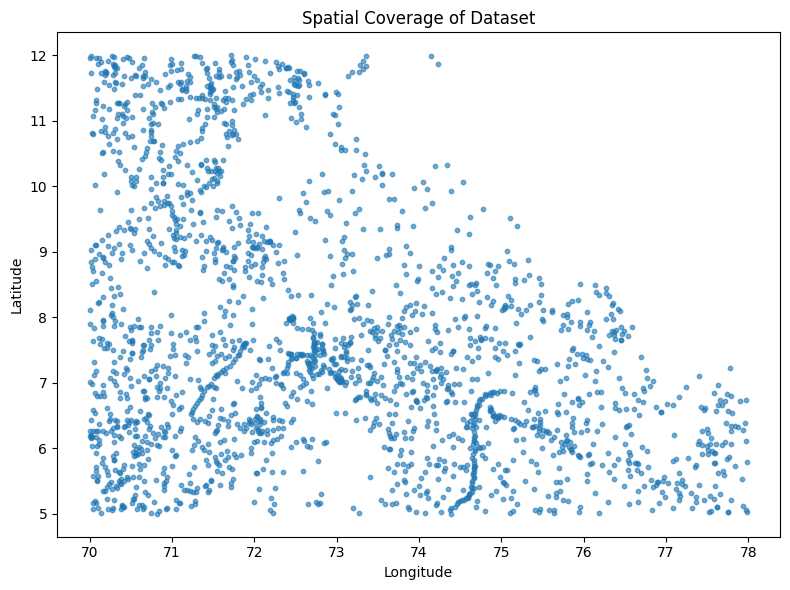

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))

# Unique spatial locations
spatial_locations = df[['LAT', 'LON']].drop_duplicates()

ax.scatter(
    spatial_locations['LON'],
    spatial_locations['LAT'],
    s=10,
    alpha=0.6
)

ax.set_title('Spatial Coverage of Dataset')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

### 2. Statistics 

Basic Statistics of Entire Data

In [13]:
# Basic statistics of numeric variables
print(df.describe())

              WMOID          CYCLE                          DATES  \
count  4.444170e+05  444417.000000                         444417   
mean   3.084926e+06     109.420553  2016-12-19 03:35:30.792431872   
min    1.900185e+06       1.000000            2005-01-04 06:48:00   
25%    2.902395e+06      50.000000            2016-07-17 23:39:00   
50%    2.902648e+06      96.000000            2017-04-04 03:27:00   
75%    2.903124e+06     160.000000            2018-05-05 14:47:00   
max    6.901545e+06     329.000000            2025-07-28 05:30:00   
std    7.430786e+05      72.998425                            NaN   

                 LON            LAT       Depth(m)     TEMP(degC)  \
count  444417.000000  444417.000000  444417.000000  444417.000000   
mean       73.024251       7.521709     630.999536      12.008054   
min        70.004000       5.002000       0.000000       2.562000   
25%        71.259000       6.327000     220.561751       7.621000   
50%        72.847000       7.2110

Statistics of Depth Points per Profile and Number of Profiles

Total rows: 444417
Number of floats (WMOID): 67
Number of unique profiles: 2201
count    2201.000000
mean      201.915947
std       243.703187
min        11.000000
25%        58.000000
50%        81.000000
75%       291.000000
max      1013.000000
dtype: float64


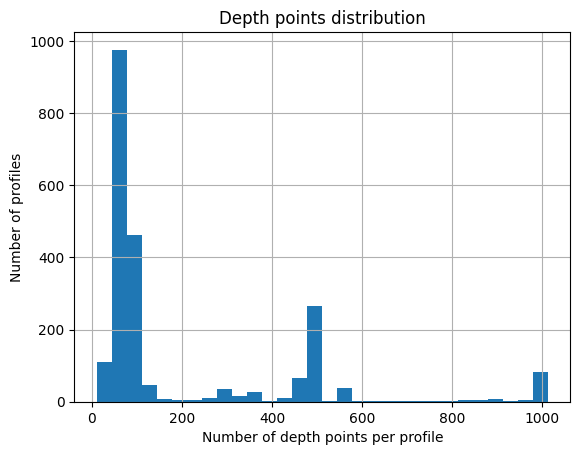

In [14]:
import matplotlib.pyplot as plt

print("Total rows:", len(df))

# Counts how many unique floats and profiles you have
num_floats = df["WMOID"].nunique()
print("Number of floats (WMOID):", num_floats)


# Checks how many rows per profile (depth points)
profile_counts = df.groupby(["WMOID", "CYCLE"]).size()
num_profiles = df.groupby(['WMOID', 'CYCLE']).ngroups
print("Number of unique profiles:", num_profiles)
print(profile_counts.describe())

profile_lengths = df.groupby(['WMOID', 'CYCLE'])['Depth(m)'].nunique()
profile_lengths.describe()
profile_lengths.hist(bins=30)
plt.xlabel("Number of depth points per profile")
plt.ylabel("Number of profiles")
plt.title("Depth points distribution")
plt.show()

Statistics of Depth

In [15]:
# Depth stats per profile
depth_stats = df.groupby(["WMOID", "CYCLE"])["Depth(m)"].agg(["min", "max", "nunique"])
print(depth_stats.describe())

               min          max      nunique
count  2201.000000  2201.000000  2201.000000
mean      5.002383  1595.821719   201.915947
std       7.412971   439.339378   243.703187
min       0.000000    39.753108    11.000000
25%       2.683662  1185.055319    58.000000
50%       4.273623  1880.557590    81.000000
75%       4.970129  1972.175721   291.000000
max     256.312543  1994.176792  1013.000000


Deepest Profile

In [16]:
# Finding the maximum depth in the entire dataset
max_depth = df['Depth(m)'].max()

print("Deepest depth:", max_depth)

# Identifying the profile (WMOID, CYCLE) where this depth occurs
deepest_profile_id = (
    df.loc[df['Depth(m)'] == max_depth, ['WMOID', 'CYCLE']]
    .iloc[0]
)

wmoid = deepest_profile_id['WMOID']
cycle = deepest_profile_id['CYCLE']

print("Deepest profile -> WMOID:", wmoid, "CYCLE:", cycle)

# Extracting the COMPLETE profile (all depths)
deepest_profile_df = df[
    (df['WMOID'] == wmoid) &
    (df['CYCLE'] == cycle)
].sort_values('Depth(m)')

# Inspecting
print(deepest_profile_df.head())
print("Number of points in profile:", len(deepest_profile_df))
print("Max depth in extracted profile:", deepest_profile_df['Depth(m)'].max())

Deepest depth: 1994.17679170719
Deepest profile -> WMOID: 2903138 CYCLE: 16
          WMOID  CYCLE               DATES       LON      LAT  Depth(m)  \
413518  2903138     16 2023-04-14 02:27:00  70.00617  7.01358  0.994000   
413519  2903138     16 2023-04-14 02:27:00  70.00617  7.01358  1.948235   
413520  2903138     16 2023-04-14 02:27:00  70.00617  7.01358  2.981985   
413521  2903138     16 2023-04-14 02:27:00  70.00617  7.01358  3.975972   
413522  2903138     16 2023-04-14 02:27:00  70.00617  7.01358  4.890435   

        TEMP(degC)  PSAL(psu)   time_days  doy   doy_sin   doy_cos  
413518   30.273001  34.162998  6673.81875  104  0.976277 -0.216527  
413519   30.275000  34.161999  6673.81875  104  0.976277 -0.216527  
413520   30.274000  34.161999  6673.81875  104  0.976277 -0.216527  
413521   30.274000  34.162998  6673.81875  104  0.976277 -0.216527  
413522   30.274000  34.162998  6673.81875  104  0.976277 -0.216527  
Number of points in profile: 1013
Max depth in extracted pr

Random Profile

In [17]:
#Geting all unique profile IDs
profiles = df[['WMOID', 'CYCLE']].drop_duplicates()
print("Total profiles:", len(profiles))

#Randomly sampling one profile
random_profile = profiles.sample(n=1, random_state=None)

wmoid = random_profile.iloc[0]['WMOID']
cycle = random_profile.iloc[0]['CYCLE']

print("Random profile -> WMOID:", wmoid, "CYCLE:", cycle)

#Extracting the complete profile
random_profile_df = df[
    (df['WMOID'] == wmoid) &
    (df['CYCLE'] == cycle)
].sort_values('Depth(m)')

#Inspecting stats
print(random_profile_df.head())
print("Number of points:", len(random_profile_df))
print("Min depth:", random_profile_df['Depth(m)'].min())
print("Max depth:", random_profile_df['Depth(m)'].max())

Total profiles: 2201
Random profile -> WMOID: 2900336 CYCLE: 111
        WMOID  CYCLE               DATES     LON    LAT   Depth(m)  \
4086  2900336    111 2005-11-03 00:51:00  70.744  6.071   4.075450   
4087  2900336    111 2005-11-03 00:51:00  70.744  6.071   9.144809   
4088  2900336    111 2005-11-03 00:51:00  70.744  6.071  18.587426   
4089  2900336    111 2005-11-03 00:51:00  70.744  6.071  29.321704   
4090  2900336    111 2005-11-03 00:51:00  70.744  6.071  39.359775   

      TEMP(degC)  PSAL(psu)   time_days  doy   doy_sin   doy_cos  
4086   27.987000  36.097000  302.752083  307 -0.842572  0.538584  
4087   27.983999  36.096001  302.752083  307 -0.842572  0.538584  
4088   27.989000  36.097000  302.752083  307 -0.842572  0.538584  
4089   27.983000  36.102001  302.752083  307 -0.842572  0.538584  
4090   27.972000  36.112000  302.752083  307 -0.842572  0.538584  
Number of points: 71
Min depth: 4.07544999061623
Max depth: 1978.11887588074


## Number of Profiles per Month

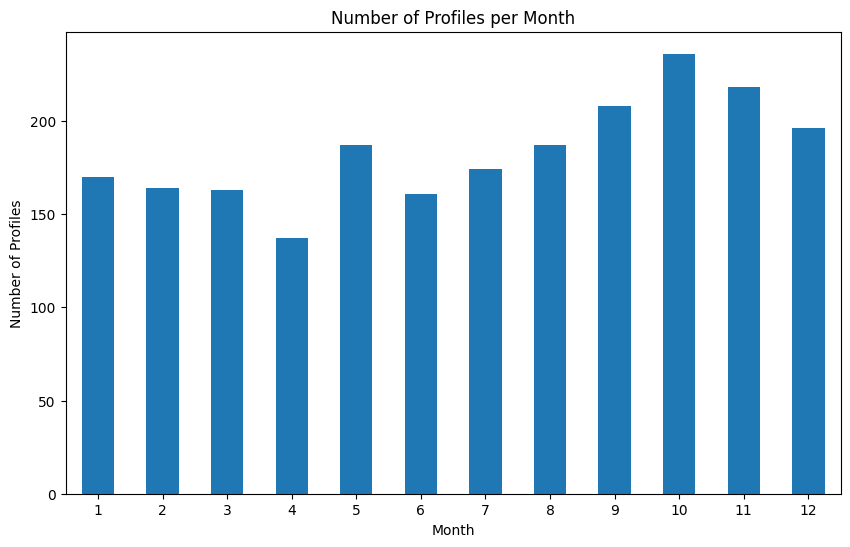

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract month
df['MONTH'] = df['DATES'].dt.month

# Count unique profiles per month
profiles_per_month = (
    df.groupby(['MONTH', 'WMOID', 'CYCLE'])
      .size()
      .groupby('MONTH')
      .size()
)

# Plot
plt.figure(figsize=(10, 6))
profiles_per_month.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Number of Profiles')
plt.title('Number of Profiles per Month')
plt.xticks(rotation=0)
plt.show()


## Monthly Spatial Coverage

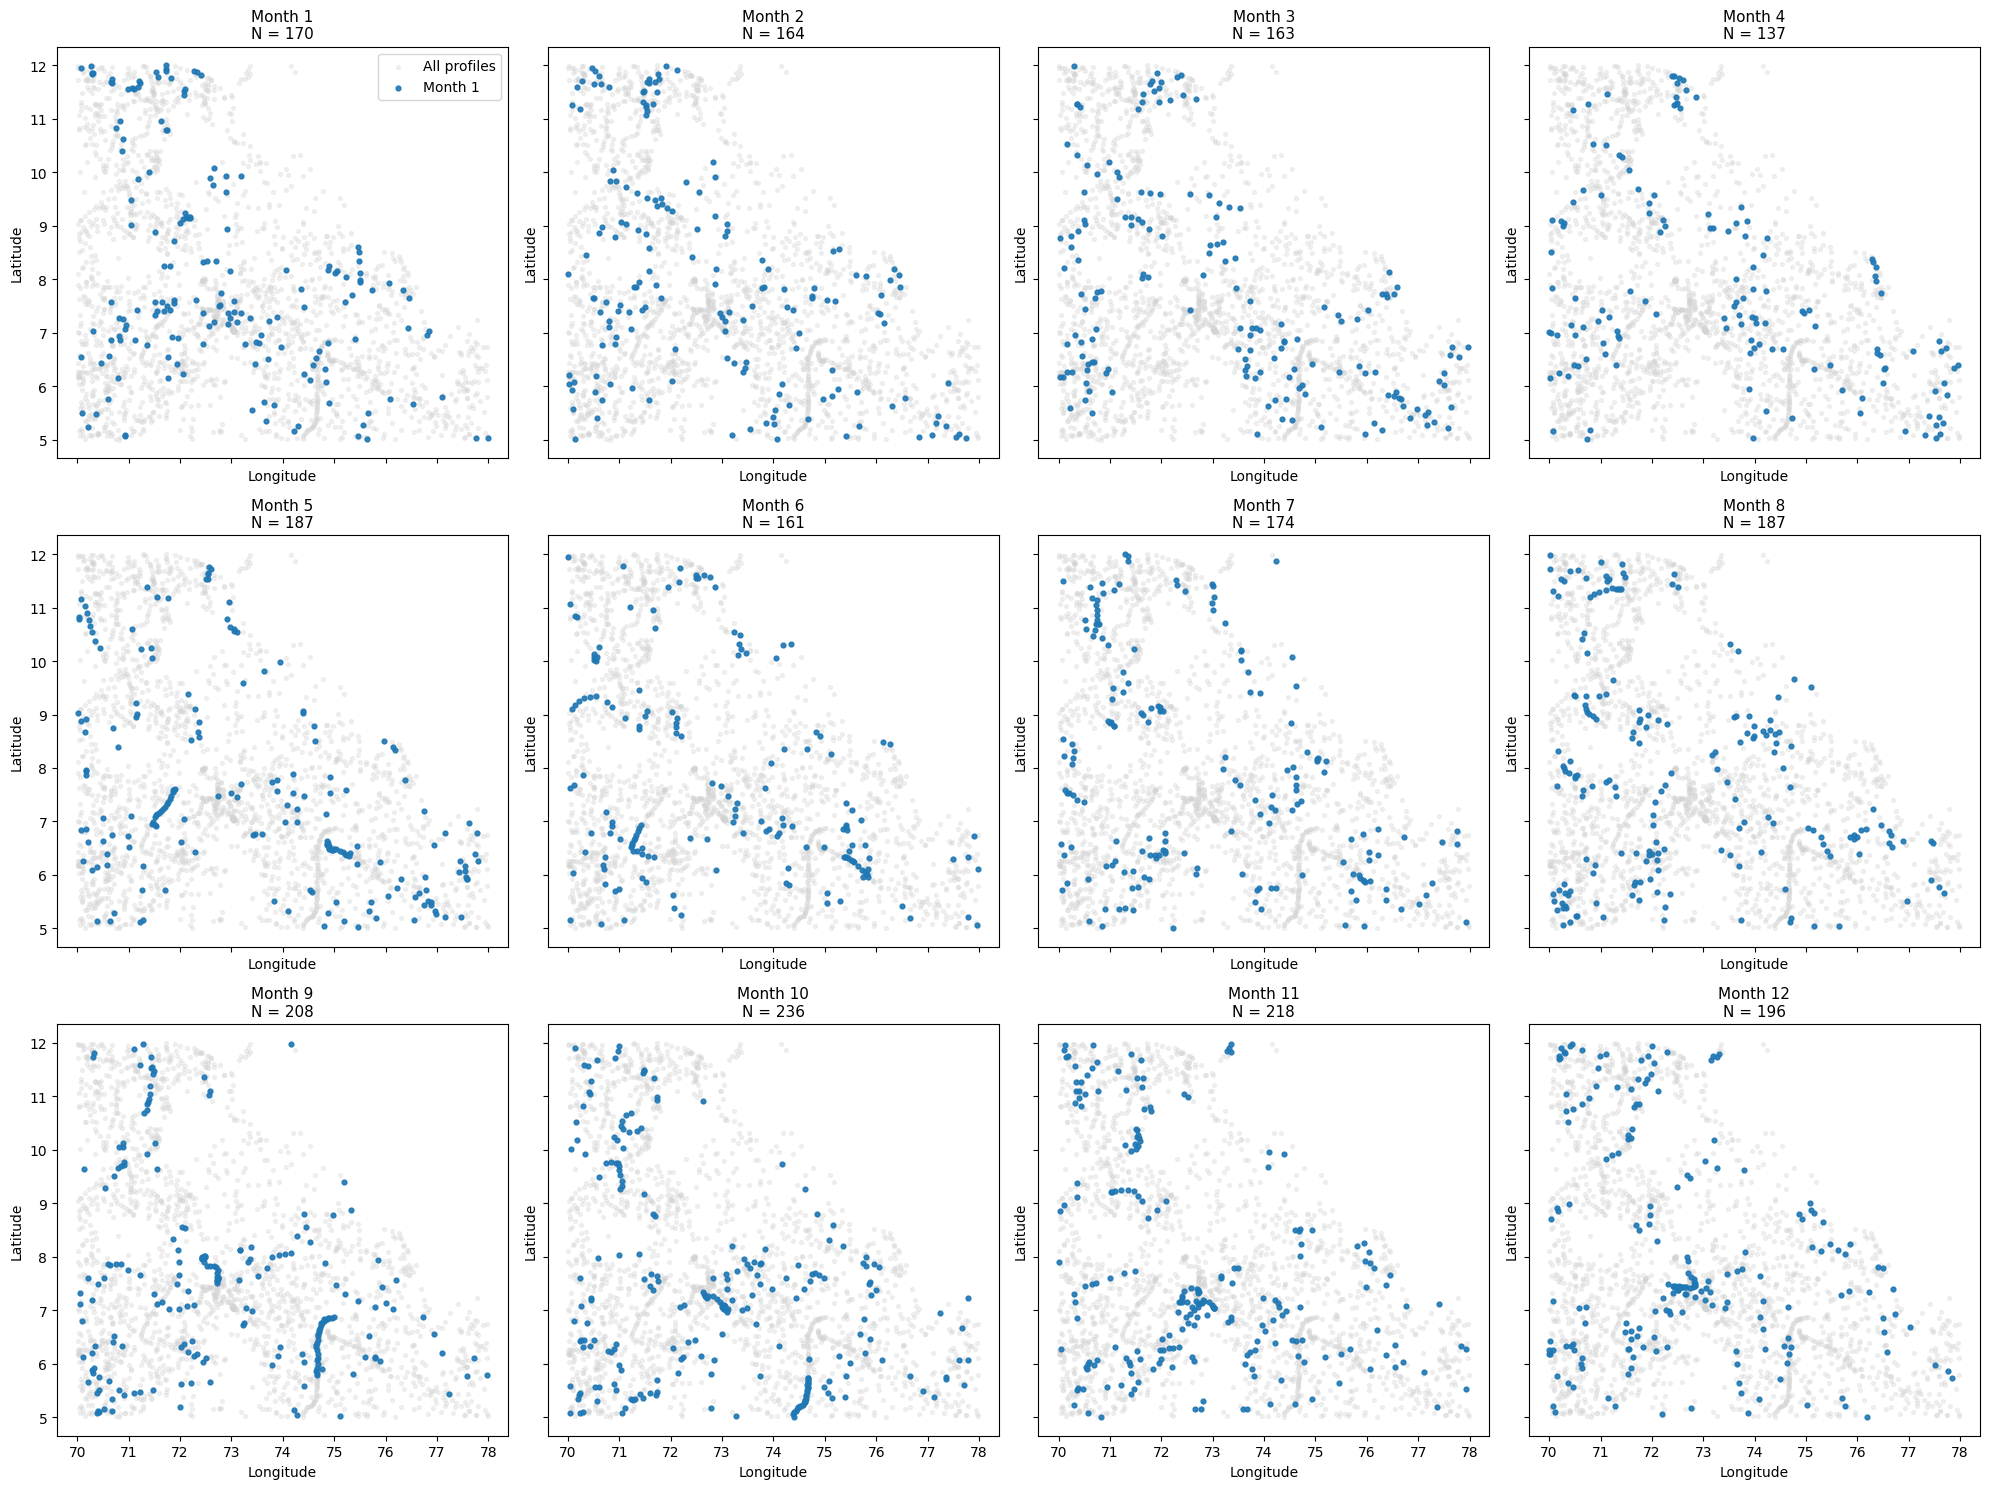

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()

df['profile_id'] = df['WMOID'].astype(str) + '_' + df['CYCLE'].astype(str)

all_profile_locations = df[['LAT', 'LON']].drop_duplicates().reset_index(drop=True)
profile_locations = df.groupby('profile_id').first().reset_index()
profile_locations['MONTH'] = profile_locations['DATES'].dt.month

for month in range(1, 13):
    ax = axes[month - 1]

    # Total spatial coverage (background)
    ax.scatter(
        all_profile_locations['LON'],
        all_profile_locations['LAT'],
        s=8,
        alpha=0.3,
        color='lightgrey',
        label='All profiles'
    )

    # Monthly profiles
    month_df = profile_locations[profile_locations['MONTH'] == month]
    ax.scatter(
        month_df['LON'],
        month_df['LAT'],
        s=12,
        alpha=0.9,
        label=f'Month {month}'
    )

    n_profiles = len(month_df)
    ax.set_title(f'Month {month}\nN = {n_profiles}', fontsize=11)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Depth-wise Distribution of Data

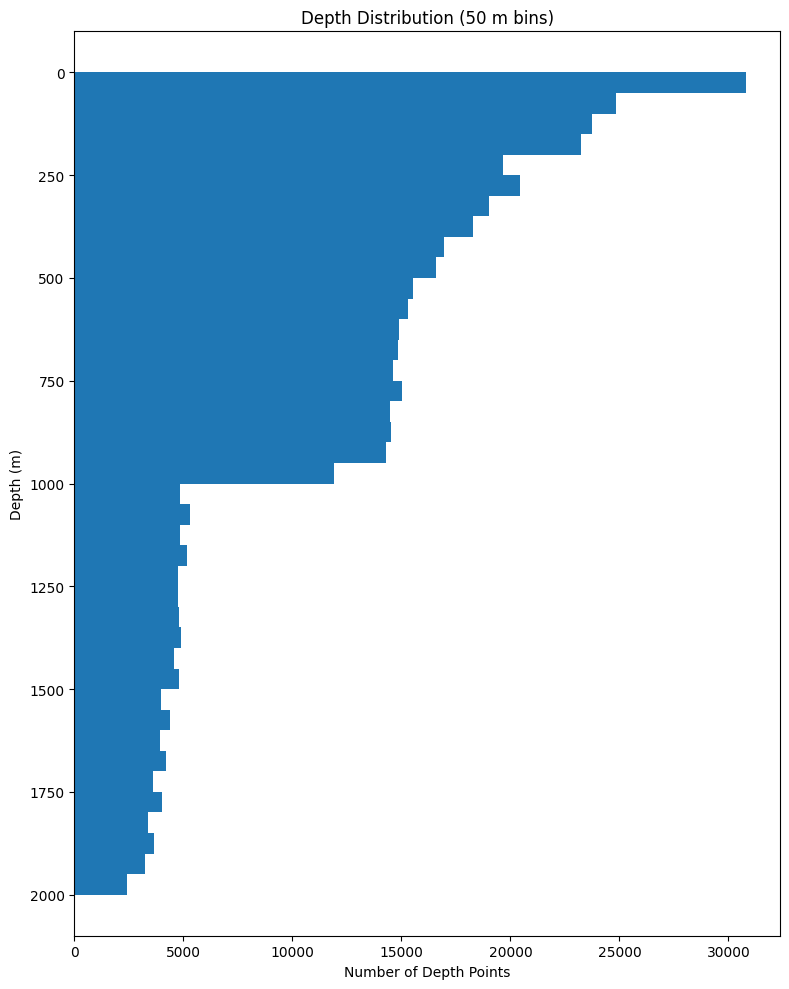

In [5]:
import numpy as np
import matplotlib.pyplot as plt

depth = df['Depth(m)'].dropna()

# Creating ? m bins
bin_size = 50
bins = np.arange(depth.min(), depth.max() + bin_size, bin_size)

# Histogram counts
counts, bin_edges = np.histogram(depth, bins=bins)

# Bin centers for plotting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plotting horizontal bar chart
plt.figure(figsize=(8, 10))
plt.barh(bin_centers, counts, height=bin_size)

plt.xlabel('Number of Depth Points')
plt.ylabel('Depth (m)')
plt.title('Depth Distribution (50 m bins)')

# Inverting y-axis so depth increases downward acc. to oceanographic convention
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()